In [300]:
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt 


## 1. `Data Loading`

In [301]:
path = "C:/Users/harsh/OneDrive/Desktop/Data Analyst/Python Visualization/Hospital Management Analysis/"

Appointment_df = pd.read_csv(path + "Appointments.csv")
Billing_df = pd.read_csv(path + "Billing.csv")
Doctors_df = pd.read_csv(path + "Doctors.csv")
Medicines_df = pd.read_csv(path + "Medicines.csv")
Patients_df = pd.read_csv(path + "Patients.csv")

## 2. `Data Understanding`

In [302]:
Appointment_df.head(5), Appointment_df.tail(5), Appointment_df.describe(), Appointment_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   AppointmentID  410 non-null    int64
 1   PatientID      410 non-null    int64
 2   DoctorID       410 non-null    int64
 3   Date           396 non-null    str  
 4   Status         410 non-null    str  
dtypes: int64(3), str(2)
memory usage: 16.1 KB


(   AppointmentID  PatientID  DoctorID        Date     Status
 0            376         38        10  2024-05-16  Completed
 1            305         49         9         NaN  Cancelled
 2            161         45         8  2024-01-22    No-show
 3            241         42         2  2024-07-24  Cancelled
 4            187        106        14  2024-01-15    No-show,
      AppointmentID  PatientID  DoctorID        Date     Status
 405            300        104        15  2024-04-01  Cancelled
 406             23         89         5  15/01/2024  completed
 407             73        104         3  2024-10-11    No-show
 408             16        112        14  2024-08-13  Completed
 409            169         64         9  2024-07-17  completed,
        AppointmentID   PatientID    DoctorID
 count     410.000000  410.000000  410.000000
 mean      199.719512   61.658537    7.714634
 std       115.529236   33.758534    4.229253
 min         1.000000    2.000000    1.000000
 25%        

 If you want your orders output as input use print 


In [303]:

""""
print(Appointment_df.head())
print(Appointment_df.tail())
Appointment_df.info()
print(Appointment_df.describe())

"""

'"\nprint(Appointment_df.head())\nprint(Appointment_df.tail())\nAppointment_df.info()\nprint(Appointment_df.describe())\n\n'

In [304]:
print(Billing_df.head(5)),
print(Billing_df.tail(5)),
Billing_df.info(),
print(Billing_df.describe())

   BillID  AppointmentID  TotalAmount PaymentMode PaymentStatus
0       1              1      2364.88        Card          Paid
1       2              2      1248.08        CARD          Paid
2       3              3      4510.09        Cash          paid
3       4              4          NaN        Card       PENDING
4       5              5      2947.40        Card          paid
     BillID  AppointmentID  TotalAmount PaymentMode PaymentStatus
395     396            396      3340.19        cash       Pending
396     397            397      2124.86         UPI       PENDING
397     398            398      1378.16        cash          Paid
398     399            399      1549.91        CARD       PENDING
399     400            400      1993.62         UPI          Paid
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   BillID         400 non-null    int

In [305]:
print(Doctors_df.head(5)),
print(Doctors_df.tail(5)),
Doctors_df.info(),
print(Doctors_df.describe())

   DoctorID             Name   Department  Experience    Fees
0         1   Dr. Ritu Joshi  Dermatology           1     NaN
1         2  Dr. Priya Yadav  ORTHOPEDICS          23  1000.0
2         3  Dr. Rahul Verma    Neurology          24   800.0
3         4  Dr. Deepak Nair   Cardiology           3   600.0
4         5   Dr. Karan Nair   Cardiology           8  1000.0
    DoctorID              Name   Department  Experience    Fees
10        11   Dr. Arjun Reddy   Cardiology          26  1200.0
11        12  Dr. Suresh Singh  ORTHOPEDICS          14  1200.0
12        13   Dr. Arjun Reddy   Cardiology          27   300.0
13        14    Dr. Ritu Joshi   Pediatrics          15     NaN
14        15  Dr. Sanjay Mehta          ENT          26   400.0
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   DoctorID    15 non-null     int64  
 1   Name        15 non-null  

In [306]:
print(Patients_df.head(5)), 
print(Patients_df.tail(5)), 
Patients_df.info(), 
print(Patients_df.describe())

   PatientID           Name   Age  Gender       City BloodGroup
0         55    Divya Gupta  84.0       F     mumbai         A+
1        105    Rohan Gupta  88.0    male  Bangalore        NaN
2         56   Kavita Gupta  60.0  female       PUNE        AB+
3         57  Anjali Sharma  71.0  female       PUNE         B+
4         34    Manoj Reddy  62.0       F      Surat         B+
     PatientID          Name   Age  Gender         City BloodGroup
123         10   Rohan Singh  88.0       F       mumbai         O+
124         73  Anjali Verma  18.0  female        Surat         B-
125         13   Arjun Singh  22.0       M         PUNE        AB-
126        108    Ritu Singh  81.0  Female   ahmedabad          A+
127         38   Priya Mehta  51.0       M   ahmedabad         NaN
<class 'pandas.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   PatientID   128 non-null    int64 

## 3. `Data Cleaning`

### 1. `Appointments.csv`



- Detect & remove duplicate rows


In [307]:
print("Duplicate rows:", Appointment_df.duplicated().sum())

Duplicate rows: 10


In [308]:
Appointment_df = Appointment_df.drop_duplicates()
print("after removing:", Appointment_df.duplicated().sum())

after removing: 0


- Normalize `Status` casing


.strip() Remove extra spaces, .capitalize() First Letter capital rest small — completed → Completed, CANCELLED → Cancelled.

In [309]:
Appointment_df['Status'] = Appointment_df['Status'].str.strip().str.capitalize()
print(Appointment_df['Status'].unique())


<StringArray>
['Completed', 'Cancelled', 'No-show']
Length: 3, dtype: str


- Convert `Date` using `pd.to_datetime(..., errors='coerce')`


format='mixed' — Pandas handle different format date automatically

errors='coerce' means that if a value cannot be converted to a valid date (or if it is already missing), Pandas will replace it with NaT (Not a Time) instead of raising an error.

In [310]:
Appointment_df['Date'] = pd.to_datetime(Appointment_df['Date'], format='mixed', errors='coerce')
print("Missing dte after conversion:", Appointment_df['Date'].isnull().sum())

Missing dte after conversion: 13


- Drop Missing dates

In [311]:
Appointment_df= Appointment_df.dropna(subset=['Date'])

- Final check 

In [312]:

print(Appointment_df.isnull().sum()),
print(Appointment_df.duplicated().sum()),
print(Appointment_df.info())

AppointmentID    0
PatientID        0
DoctorID         0
Date             0
Status           0
dtype: int64
0
<class 'pandas.DataFrame'>
Index: 387 entries, 0 to 409
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   AppointmentID  387 non-null    int64         
 1   PatientID      387 non-null    int64         
 2   DoctorID       387 non-null    int64         
 3   Date           387 non-null    datetime64[us]
 4   Status         387 non-null    str           
dtypes: datetime64[us](1), int64(3), str(1)
memory usage: 18.1 KB
None


### 2. `Billing.csv`

- Fix negative `TotalAmount` values

In [313]:
Billing_df['TotalAmount'] = Billing_df['TotalAmount'].abs()

- Filling Missing TotalAmount with median

In [314]:
medium_amount = Billing_df['TotalAmount'].median()

In [315]:
Billing_df['TotalAmount'] = Billing_df['TotalAmount'].fillna(medium_amount)

- PaymentMode Normlize form

In [316]:
Billing_df['PaymentMode'] = Billing_df['PaymentMode'].str.strip().str.title()

In [317]:
Billing_df['PaymentStatus'] = Billing_df['PaymentStatus'].str.strip().str.title()

- Final Check

In [318]:
print(Billing_df.isnull().sum()),
print(Billing_df.duplicated().sum()),
print(Billing_df['PaymentMode'].unique()),
print(Billing_df['PaymentStatus'].unique())

BillID           0
AppointmentID    0
TotalAmount      0
PaymentMode      0
PaymentStatus    0
dtype: int64
0
<StringArray>
['Card', 'Cash', 'Upi', 'Insurance']
Length: 4, dtype: str
<StringArray>
['Paid', 'Pending']
Length: 2, dtype: str


#### 3. `Doctors.csv`


- Clean: strip spaces + title case


In [319]:
Doctors_df['Name'] = Doctors_df['Name'].str.strip().str.title()

In [320]:
Doctors_df['Department'] = Doctors_df['Department'].str.strip().str.title()

- Filling missing `Fees` using department-wise average

In [321]:
Doctors_df['Fees'] = Doctors_df['Fees'].fillna(
    Doctors_df.groupby('Department')['Fees'].transform('mean')
)

In [322]:
Doctors_df['Fees'] = Doctors_df['Fees'].fillna(Doctors_df['Fees'].mean())


- Final Check

In [323]:
print(Doctors_df.isnull().sum()),
print(Doctors_df.duplicated().sum())

DoctorID      0
Name          0
Department    0
Experience    0
Fees          0
dtype: int64
0


In [324]:
Doctors_df

,DoctorID,Name,Department,Experience,Fees
0,1,Dr. Ritu Joshi,Dermatology,1,1000.000000
1,2,Dr. Priya Yadav,Orthopedics,23,1000.000000
2,3,Dr. Rahul Verma,Neurology,24,800.000000
3,4,Dr. Deepak Nair,Cardiology,3,600.000000
4,5,Dr. Karan Nair,Cardiology,8,1000.000000
5,6,Dr. Neha Joshi,General Medicine,27,500.000000
6,7,Dr. Karan Patel,Ent,1,500.000000
7,8,Dr. Kavita Verma,Dermatology,5,1200.000000
8,9,Dr. Suresh Mehta,Cardiology,14,500.000000
9,10,Dr. Suresh Yadav,Dermatology,1,800.000000


### 4.  `Medicines.csv `

- Filling missing `Price` using medicine-wise average

In [325]:
Medicines_df['Price'] = Medicines_df['Price'].fillna(
    Medicines_df.groupby('MedicineName')['Price'].transform('mean')
) 

In [326]:
print(Medicines_df.isnull().sum()),
print(Medicines_df.duplicated().sum())

MedicineID       0
AppointmentID    0
MedicineName     0
Quantity         0
Price            0
dtype: int64
0


In [327]:
Medicines_df

,MedicineID,AppointmentID,MedicineName,Quantity,Price
0,1,180,Pantoprazole,6,199.86
1,2,331,Azithromycin,4,142.82
2,3,312,Metformin,1,213.49
3,4,155,Ibuprofen,9,155.66
4,5,201,Metformin,1,198.11
...,...,...,...,...,...
295,296,157,Vitamin D3,9,36.12
296,297,42,Metformin,3,223.91
297,298,376,Azithromycin,2,224.11
298,299,324,Paracetamol,10,148.94


### 5. ` Patients.csv `

- Detect & remove duplicate rows

In [328]:
print("Duplicates:", Patients_df.duplicated().sum()),
Patients_df.isnull().sum()

Duplicates: 8


PatientID      0
Name           0
Age            1
Gender         0
City           7
BloodGroup    23
dtype: int64

In [329]:
Patients_df.head(5)

,PatientID,Name,Age,Gender,City,BloodGroup
0,55,Divya Gupta,84.0,F,mumbai,A+
1,105,Rohan Gupta,88.0,male,Bangalore,NaN
2,56,Kavita Gupta,60.0,female,PUNE,AB+
3,57,Anjali Sharma,71.0,female,PUNE,B+
4,34,Manoj Reddy,62.0,F,Surat,B+


In [330]:
Patients_df = Patients_df.drop_duplicates()

- Clean spaces + Case

In [331]:
Patients_df['City'] = Patients_df['City'].str.strip().str.title()

- Gender Normlization

In [332]:
Patients_df['Gender'] = Patients_df['Gender'].replace({
    'M': 'Male', 'F': 'Female',
    'male': 'Male', 'female': 'Female'
})


In [333]:
Patients_df

,PatientID,Name,Age,Gender,City,BloodGroup
0,55,Divya Gupta,84.0,Female,Mumbai,A+
1,105,Rohan Gupta,88.0,Male,Bangalore,NaN
2,56,Kavita Gupta,60.0,Female,Pune,AB+
3,57,Anjali Sharma,71.0,Female,Pune,B+
4,34,Manoj Reddy,62.0,Female,Surat,B+
...,...,...,...,...,...,...
123,10,Rohan Singh,88.0,Female,Mumbai,O+
124,73,Anjali Verma,18.0,Female,Surat,B-
125,13,Arjun Singh,22.0,Male,Pune,AB-
126,108,Ritu Singh,81.0,Female,Ahmedabad,A+


- Fixing `Age`: replacing invalid values (negative, 0, >100) with NaN, then Fillig with median

In [334]:
''' 
Patients_df['Age'] = np.where(
    (Patients_df['Age'] >= 0) & (Patients_df['Age'] <= 100),
    Patients_df['Age'],
    None
)
'''

Patients_df.loc[Patients_df['Age'] < 0, 'Age'] = None,
Patients_df.loc[Patients_df['Age'] > 100, 'Age'] = None

In [335]:
median_age = Patients_df['Age'].median()
Patients_df['Age'] = Patients_df['Age'].fillna(median_age)


- Filling missing `BloodGroup` - `City` with "Unknown"

In [336]:
Patients_df['BloodGroup'] = Patients_df['BloodGroup'].fillna('Unknowm')

In [337]:
Patients_df['City'] = Patients_df['City'].fillna('Unknown')

- Final Check

In [338]:
print("Duplicates:", Patients_df.duplicated().sum()),
Patients_df.isnull().sum()

Duplicates: 0


PatientID     0
Name          0
Age           0
Gender        0
City          0
BloodGroup    0
dtype: int64

##### `Final check for all the tables `

In [339]:
for name, df in [('Patients', Patients_df),
                  ('Doctors', Doctors_df), 
                  ('Appointments', Appointment_df), 
                  ('Medicines', Medicines_df), 
                  ('Billing', Billing_df)]:
    print(f"-- {name} --")
    print("Nulls:", df.isnull().sum().sum())
    print("Duplicates:", df.duplicated().sum())
    print()


-- Patients --
Nulls: 0
Duplicates: 0

-- Doctors --
Nulls: 0
Duplicates: 0

-- Appointments --
Nulls: 0
Duplicates: 0

-- Medicines --
Nulls: 0
Duplicates: 0

-- Billing --
Nulls: 0
Duplicates: 0



## 4. `Data Transformation`

- AgeGroup Column Using pd.cut() --> pd.cut (Instead of working with many different numeric values, you convert them into meaningful categories)

In [340]:
Patients_df['AgeGroup'] = pd.cut(
    Patients_df['Age'],
    bins= [-1, 12, 19, 59, 159],
    labels= ['Child', 'Teens', 'Adults', 'Senior']
)

- HighValueBill Flag 

In [341]:
print(Billing_df['TotalAmount'].describe())

count     400.000000
mean     2667.506125
std      1306.622488
min       302.450000
25%      1565.137500
50%      2619.260000
75%      3643.717500
max      4989.380000
Name: TotalAmount, dtype: float64


In [342]:
Billing_df['HighValueBill'] = np.where (Billing_df['TotalAmount']> 3000, 1, 0)

print(Billing_df[['TotalAmount', 'HighValueBill']].head(10))
print(Billing_df['HighValueBill'].value_counts())

   TotalAmount  HighValueBill
0      2364.88              0
1      1248.08              0
2      4510.09              1
3      2619.26              0
4      2947.40              0
5      3568.93              1
6       954.86              0
7      3140.76              1
8      2619.26              0
9      1254.39              0
HighValueBill
0    244
1    156
Name: count, dtype: int64


- Extracting `Month` and `Weekday` from Appointment `Date` using `.dt.month_name()` / `.dt.day_name()`

In [343]:
Appointment_df['Month'] = Appointment_df['Date'].dt.month_name()
Appointment_df['Weekday'] = Appointment_df['Date'].dt.day_name()

print(Appointment_df[['Date', 'Month', 'Weekday']].head(10))

         Date     Month    Weekday
0  2024-05-16       May   Thursday
2  2024-01-22   January     Monday
3  2024-07-24      July  Wednesday
4  2024-01-15   January     Monday
5  2024-12-24  December    Tuesday
6  2024-08-07    August  Wednesday
7  2024-04-24     April  Wednesday
8  2024-12-06  December     Friday
9  2024-06-11      June    Tuesday
10 2024-12-16  December     Monday


In [344]:
print(Appointment_df['Date'].dtype)

datetime64[us]


In [345]:
print(Patients_df.columns.tolist())
print(Billing_df.columns.tolist())
print(Appointment_df.columns.tolist())


['PatientID', 'Name', 'Age', 'Gender', 'City', 'BloodGroup', 'AgeGroup']
['BillID', 'AppointmentID', 'TotalAmount', 'PaymentMode', 'PaymentStatus', 'HighValueBill']
['AppointmentID', 'PatientID', 'DoctorID', 'Date', 'Status', 'Month', 'Weekday']


## 5. ` Data Merging`

In [346]:
print(Appointment_df.columns.tolist())
print(Patients_df.columns.tolist())
print(Billing_df.columns.tolist())
print(Medicines_df.columns.tolist())
print(Doctors_df.columns.tolist())

['AppointmentID', 'PatientID', 'DoctorID', 'Date', 'Status', 'Month', 'Weekday']
['PatientID', 'Name', 'Age', 'Gender', 'City', 'BloodGroup', 'AgeGroup']
['BillID', 'AppointmentID', 'TotalAmount', 'PaymentMode', 'PaymentStatus', 'HighValueBill']
['MedicineID', 'AppointmentID', 'MedicineName', 'Quantity', 'Price']
['DoctorID', 'Name', 'Department', 'Experience', 'Fees']


`Appointment + Patients (on patientID) Merge`

In [347]:
merge_1_df = pd.merge(Appointment_df, Patients_df, 
                    on='PatientID', how = 'left')
print(merge_1_df.shape)
print(merge_1_df.head())

(387, 13)
   AppointmentID  PatientID  DoctorID       Date     Status     Month  \
0            376         38        10 2024-05-16  Completed       May   
1            161         45         8 2024-01-22    No-show   January   
2            241         42         2 2024-07-24  Cancelled      July   
3            187        106        14 2024-01-15    No-show   January   
4            174         92        12 2024-12-24    No-show  December   

     Weekday          Name   Age  Gender       City BloodGroup AgeGroup  
0   Thursday   Priya Mehta  51.0    Male  Ahmedabad    Unknowm   Adults  
1     Monday  Anjali Mehta  73.0  Female      Surat    Unknowm   Senior  
2  Wednesday   Rohan Mehta  51.0  Female      Delhi         A-   Adults  
3     Monday  Simran Singh  63.0  Female       Pune         O+   Senior  
4    Tuesday  Simran Verma  89.0    Male     Mumbai         O-   Senior  


`Doctors + merge_1_df on (DoctorID) Merge`

In [348]:
merge_2_df = pd.merge(merge_1_df, Doctors_df, 
                     on='DoctorID', how='left')
print(merge_2_df.shape)
print(merge_2_df.head())


(387, 17)
   AppointmentID  PatientID  DoctorID       Date     Status     Month  \
0            376         38        10 2024-05-16  Completed       May   
1            161         45         8 2024-01-22    No-show   January   
2            241         42         2 2024-07-24  Cancelled      July   
3            187        106        14 2024-01-15    No-show   January   
4            174         92        12 2024-12-24    No-show  December   

     Weekday        Name_x   Age  Gender       City BloodGroup AgeGroup  \
0   Thursday   Priya Mehta  51.0    Male  Ahmedabad    Unknowm   Adults   
1     Monday  Anjali Mehta  73.0  Female      Surat    Unknowm   Senior   
2  Wednesday   Rohan Mehta  51.0  Female      Delhi         A-   Adults   
3     Monday  Simran Singh  63.0  Female       Pune         O+   Senior   
4    Tuesday  Simran Verma  89.0    Male     Mumbai         O-   Senior   

             Name_y   Department  Experience         Fees  
0  Dr. Suresh Yadav  Dermatology        

In [349]:
mergedName_df = merge_2_df.rename(columns={'Name_x': 'PatientName', 'Name_y': 'DoctorName'})

In [350]:
mergedName_df

,AppointmentID,PatientID,DoctorID,Date,Status,Month,Weekday,PatientName,Age,Gender,City,BloodGroup,AgeGroup,DoctorName,Department,Experience,Fees
0,376,38,10,2024-05-16,Completed,May,Thursday,Priya Mehta,51.0,Male,Ahmedabad,Unknowm,Adults,Dr. Suresh Yadav,Dermatology,1,800.000000
1,161,45,8,2024-01-22,No-show,January,Monday,Anjali Mehta,73.0,Female,Surat,Unknowm,Senior,Dr. Kavita Verma,Dermatology,5,1200.000000
2,241,42,2,2024-07-24,Cancelled,July,Wednesday,Rohan Mehta,51.0,Female,Delhi,A-,Adults,Dr. Priya Yadav,Orthopedics,23,1000.000000
3,187,106,14,2024-01-15,No-show,January,Monday,Simran Singh,63.0,Female,Pune,O+,Senior,Dr. Ritu Joshi,Pediatrics,15,785.714286
4,174,92,12,2024-12-24,No-show,December,Tuesday,Simran Verma,89.0,Male,Mumbai,O-,Senior,Dr. Suresh Singh,Orthopedics,14,1200.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
382,300,104,15,2024-04-01,Cancelled,April,Monday,Anjali Verma,8.0,Male,Mumbai,O+,Child,Dr. Sanjay Mehta,Ent,26,400.000000
383,23,89,5,2024-01-15,Completed,January,Monday,Deepak Gupta,53.0,Male,Pune,B+,Adults,Dr. Karan Nair,Cardiology,8,1000.000000
384,73,104,3,2024-10-11,No-show,October,Friday,Anjali Verma,8.0,Male,Mumbai,O+,Child,Dr. Rahul Verma,Neurology,24,800.000000
385,16,112,14,2024-08-13,Completed,August,Tuesday,Ritu Yadav,33.0,Male,Delhi,O-,Adults,Dr. Ritu Joshi,Pediatrics,15,785.714286


` Billing + Appointment on (AppointmentID) Merge`

In [351]:
master_df = pd.merge(mergedName_df, Billing_df, 
                     on='AppointmentID', how = 'left')
print(master_df.shape)
print(master_df.head())

(387, 22)
   AppointmentID  PatientID  DoctorID       Date     Status     Month  \
0            376         38        10 2024-05-16  Completed       May   
1            161         45         8 2024-01-22    No-show   January   
2            241         42         2 2024-07-24  Cancelled      July   
3            187        106        14 2024-01-15    No-show   January   
4            174         92        12 2024-12-24    No-show  December   

     Weekday   PatientName   Age  Gender  ... AgeGroup        DoctorName  \
0   Thursday   Priya Mehta  51.0    Male  ...   Adults  Dr. Suresh Yadav   
1     Monday  Anjali Mehta  73.0  Female  ...   Senior  Dr. Kavita Verma   
2  Wednesday   Rohan Mehta  51.0  Female  ...   Adults   Dr. Priya Yadav   
3     Monday  Simran Singh  63.0  Female  ...   Senior    Dr. Ritu Joshi   
4    Tuesday  Simran Verma  89.0    Male  ...   Senior  Dr. Suresh Singh   

    Department Experience         Fees  BillID  TotalAmount  PaymentMode  \
0  Dermatology    

In [352]:
master_df

,AppointmentID,PatientID,DoctorID,Date,Status,Month,Weekday,PatientName,Age,Gender,...,AgeGroup,DoctorName,Department,Experience,Fees,BillID,TotalAmount,PaymentMode,PaymentStatus,HighValueBill
0,376,38,10,2024-05-16,Completed,May,Thursday,Priya Mehta,51.0,Male,...,Adults,Dr. Suresh Yadav,Dermatology,1,800.000000,376,503.98,Insurance,Paid,0
1,161,45,8,2024-01-22,No-show,January,Monday,Anjali Mehta,73.0,Female,...,Senior,Dr. Kavita Verma,Dermatology,5,1200.000000,161,630.96,Cash,Pending,0
2,241,42,2,2024-07-24,Cancelled,July,Wednesday,Rohan Mehta,51.0,Female,...,Adults,Dr. Priya Yadav,Orthopedics,23,1000.000000,241,380.66,Cash,Pending,0
3,187,106,14,2024-01-15,No-show,January,Monday,Simran Singh,63.0,Female,...,Senior,Dr. Ritu Joshi,Pediatrics,15,785.714286,187,3458.52,Upi,Paid,1
4,174,92,12,2024-12-24,No-show,December,Tuesday,Simran Verma,89.0,Male,...,Senior,Dr. Suresh Singh,Orthopedics,14,1200.000000,174,1504.17,Card,Paid,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
382,300,104,15,2024-04-01,Cancelled,April,Monday,Anjali Verma,8.0,Male,...,Child,Dr. Sanjay Mehta,Ent,26,400.000000,300,3495.27,Cash,Paid,1
383,23,89,5,2024-01-15,Completed,January,Monday,Deepak Gupta,53.0,Male,...,Adults,Dr. Karan Nair,Cardiology,8,1000.000000,23,873.81,Insurance,Paid,0
384,73,104,3,2024-10-11,No-show,October,Friday,Anjali Verma,8.0,Male,...,Child,Dr. Rahul Verma,Neurology,24,800.000000,73,1335.13,Card,Paid,0
385,16,112,14,2024-08-13,Completed,August,Tuesday,Ritu Yadav,33.0,Male,...,Adults,Dr. Ritu Joshi,Pediatrics,15,785.714286,16,1689.48,Card,Paid,0


**Medicines.csv is kept separate** — not merged with `master_df`, because one appointment can have multiple medicines.

 Merging would duplicate the appointment/patient/billing rows (one row per medicine instead of one row per appointment), which would break revenue and department-level calculations.

 `Medicines_df` is analyzed independently.


In [353]:
Medicines_df['MedicineName'].value_counts()
Medicines_df.groupby('MedicineName')['Quantity'].sum().sort_values(ascending=False)

MedicineName
Azithromycin    236
Ibuprofen       188
Paracetamol     188
Amoxicillin     177
Pantoprazole    175
Cough Syrup     174
ORS             167
Cetrizine       150
Metformin       121
Vitamin D3      107
Name: Quantity, dtype: int64

- `Final Check`

In [354]:
print("Original appointments rows:",Appointment_df.shape[0])
print("Master_df rows:", master_df.shape[0])
print(master_df.isnull().sum())

Original appointments rows: 387
Master_df rows: 387
AppointmentID    0
PatientID        0
DoctorID         0
Date             0
Status           0
Month            0
Weekday          0
PatientName      0
Age              0
Gender           0
City             0
BloodGroup       0
AgeGroup         0
DoctorName       0
Department       0
Experience       0
Fees             0
BillID           0
TotalAmount      0
PaymentMode      0
PaymentStatus    0
HighValueBill    0
dtype: int64


## 6. ` Exploratory Data Analysis (EDA)`

- ` Value_Count() - Distribution Check `

In [355]:
# It will show how many appointments are Completed, Cancelled, or No-show, which departments are the busiest, and which payment methods are used the most.

print("status Distribution:")
print(master_df['Status'].value_counts())

print("\nDepartment Distribution:")
print(master_df['Department'].value_counts())

print("\nPaymentMode Distribution:")
print(master_df['PaymentMode'].value_counts())

print("\nGender Distribution:")
print(master_df['Gender'].value_counts())

status Distribution:
Status
Cancelled    166
Completed    144
No-show       77
Name: count, dtype: int64

Department Distribution:
Department
Cardiology          142
Dermatology          66
Orthopedics          48
Ent                  46
General Medicine     34
Neurology            29
Pediatrics           22
Name: count, dtype: int64

PaymentMode Distribution:
PaymentMode
Card         128
Cash         118
Insurance     72
Upi           69
Name: count, dtype: int64

Gender Distribution:
Gender
Female    219
Male      168
Name: count, dtype: int64


- `unique()` - how maany unique values are there

In [356]:
print("Unique Patients:", master_df['PatientID'].nunique())
print("Unique Doctors:", master_df['DoctorID'].nunique())
print("Unique Cities:", master_df['City'].nunique())


Unique Patients: 114
Unique Doctors: 15
Unique Cities: 7


- `GroupBy()`- Department-wise Appointment count

In [357]:
dept_count = master_df.groupby('Department')['AppointmentID'].count().sort_values(ascending=False)
print(dept_count)

Department
Cardiology          142
Dermatology          66
Orthopedics          48
Ent                  46
General Medicine     34
Neurology            29
Pediatrics           22
Name: AppointmentID, dtype: int64


- `Department-wise Avg Bill`

In [358]:
dept_revenue = master_df.groupby('Department')['TotalAmount'].sum().sort_values(ascending=False)
print(dept_revenue)

Department
Cardiology          378700.28
Dermatology         174967.35
Ent                 129725.85
Orthopedics         120890.54
General Medicine     95906.93
Neurology            68681.14
Pediatrics           62486.13
Name: TotalAmount, dtype: float64


- `Pivot_tabel()` -  Department vs AgeGroup

In [359]:
pivot = pd.pivot_table( master_df,
                       index = 'Department',
                       columns = 'AgeGroup',
                       values = 'AppointmentID',
                       aggfunc = 'count',
                       fill_value = 0)
print(pivot) 

AgeGroup          Child  Teens  Adults  Senior
Department                                    
Cardiology           31      6      60      45
Dermatology          11      4      23      28
Ent                   8      1      15      22
General Medicine      5      1      11      17
Neurology             5      0      12      12
Orthopedics          10      3      14      21
Pediatrics            5      0       7      10


- `Query()` - Filtering example

In [360]:
#Cancelled Appointment
cancelled = master_df.query("Status == 'Cancelled'")
print("Total cancelled:", cancelled.shape[0])

#High Value bills (>3000)
high_bills = master_df.query("TotalAmount > 3000")
print("High value bills count:", high_bills.shape[0])

#Specific department + specific status combo
cardio_cancelled = master_df.query("Department == 'Cardiology' and Status == 'Cancelled'")
print("Cardiology Cancelled:", cardio_cancelled.shape[0])


Total cancelled: 166
High value bills count: 153
Cardiology Cancelled: 53


`# isin - To check multiple values`

In [361]:
selected_depts = master_df[master_df['Department'].isin(['Cardiology', 'Neurology'])]
print(selected_depts.shape[0])

171


## 7. `NumPy-based Statistical Analysis`

In [381]:
Billing_df.loc[Billing_df['TotalAmount'].idxmin()]

BillID               28
AppointmentID        28
TotalAmount      302.45
PaymentMode         Upi
PaymentStatus      Paid
HighValueBill         0
Name: 27, dtype: object

`Age Statistics - Numpy`

In [391]:
print("Age Statistics:" )
print("\nMean:", np.mean(master_df['Age']))
print("\nMedian:", np.median(master_df['Age']))
print("\nMax:", np.max(master_df['Age']))
print("\nMin:", np.min(master_df['Age']))
print("\nStd Dev:", (master_df['Age']))
print("\nVariance:", (master_df['Age']))

Age Statistics:

Mean: 45.60723514211886

Median: 48.0

Max: 89.0

Min: 0.0

Std Dev: 0      51.0
1      73.0
2      51.0
3      63.0
4      89.0
       ... 
382     8.0
383    53.0
384     8.0
385    33.0
386    36.0
Name: Age, Length: 387, dtype: float64

Variance: 0      51.0
1      73.0
2      51.0
3      63.0
4      89.0
       ... 
382     8.0
383    53.0
384     8.0
385    33.0
386    36.0
Name: Age, Length: 387, dtype: float64


`Total Amount Statistics`

In [401]:
print("TotalAmount Statistics")
print("\nMean:", np.mean(master_df['TotalAmount']))
print("Median:", np.median(master_df['TotalAmount']))
print("Std Dev:", np.std(master_df['TotalAmount']))

TotalAmount Statistics

Mean: 2665.0083204134366
Median: 2619.26
Std Dev: 1316.201865860671


`Revenue calculation`

In [406]:
# Overall Total Revenue

total_revenue = np.sum(master_df['TotalAmount'])
print("Total Revenue:", total_revenue)

Total Revenue: 1031358.22


In [415]:
# Department wise Revenue

dept_revenue = master_df.groupby('Department')['TotalAmount'].sum().sort_values(ascending=False)
print(dept_revenue)

Department
Cardiology          378700.28
Dermatology         174967.35
Ent                 129725.85
Orthopedics         120890.54
General Medicine     95906.93
Neurology            68681.14
Pediatrics           62486.13
Name: TotalAmount, dtype: float64


## 8. `Visualizations`

-  `Departmetn-wise Total Revenue` - (Bar Chart)

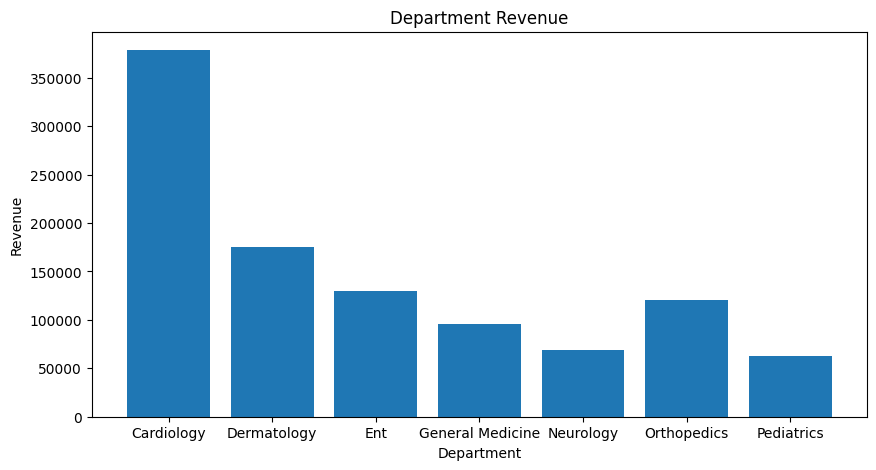

In [447]:
data = master_df.groupby('Department')['TotalAmount'].sum()

plt.figure(figsize=(10,5))

plt.bar(data.index, data.values)
plt.title("Department Revenue")
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.show()

- `Monthly Appointment Trend`

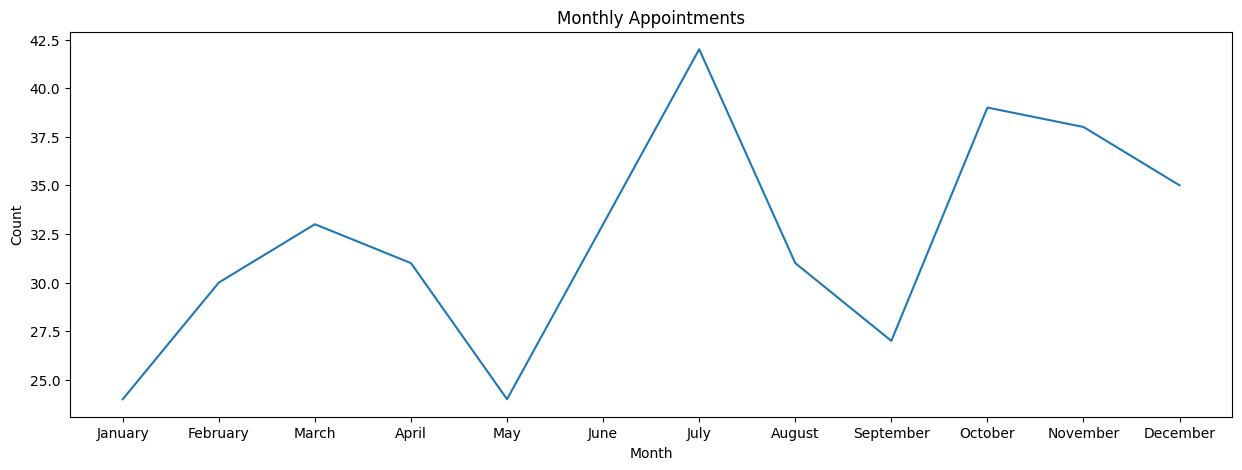

In [481]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

data = master_df['Month'].value_counts().reindex(month_order)

plt.figure(figsize=(15,5))


plt.plot(data.index, data.values)
plt.title("Monthly Appointments")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

- `Age Distribution` (Histogram)

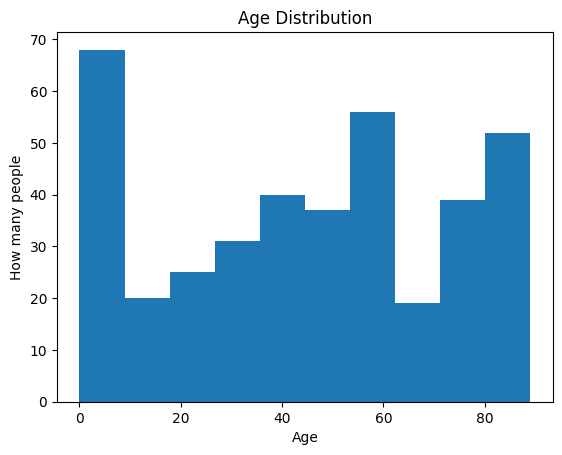

In [474]:
plt.hist(master_df['Age'])

plt.Figure(figsize= (10,5))

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("How many people")

plt.show()

- Payement Mode 

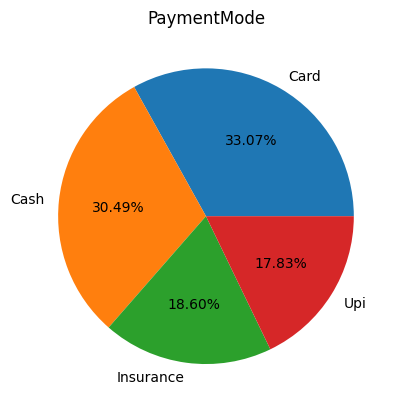

In [500]:
data = master_df['PaymentMode'].value_counts()

plt.pie(data.values, labels=data.index, autopct='%1.2f%%')
plt.title("PaymentMode")
plt.show()

- `Doctor Experience vs Fees` - (Scatter Chart)

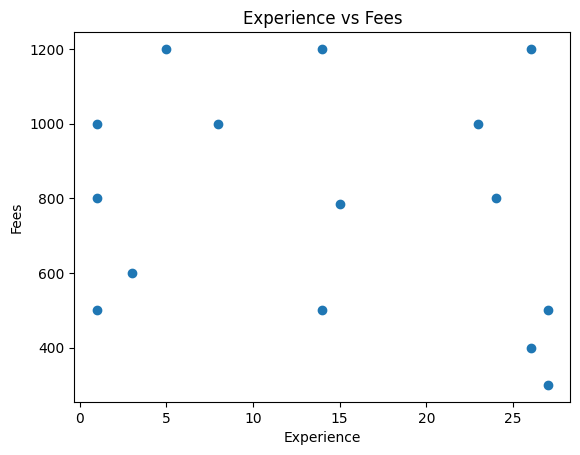

In [501]:
plt.scatter(Doctors_df['Experience'], Doctors_df['Fees'])
plt.title("Experience vs Fees")
plt.xlabel("Experience")
plt.ylabel("Fees")

plt.show()

## 9. `Buiness Insights`


1. **Top Revenue Department:** Cardiology department generates the highest 
   revenue (₹3,78,700), significantly ahead of other departments. This 
   suggests Cardiology has the highest patient load and revenue contribution 
   — the hospital could consider investing more in staffing, equipment, or 
   operating hours for this department.

2. **Peak Appointment Month:** July recorded the highest number of 
   appointments (42), indicating a seasonal spike. This could be linked to 
   weather-related illnesses or post-monsoon health issues — useful for 
   planning staff availability during this period.

3. **Most Common Age Group:** Senior citizens (155 visits) form the largest 
   patient group, followed by Adults (142), Children (75), and Teens (15). 
   This shows the hospital primarily serves an older demographic, which 
   aligns with Cardiology being the top-revenue department (seniors often 
   need cardiac care) — the two insights support each other.

4. **Cancellation Rate:** The overall cancellation rate is notably high at 
   42.89%. Cardiology alone accounts for 53 cancellations — the highest 
   among all departments (roughly 32% of all cancellations). This is a 
   red flag: despite being the top revenue generator, Cardiology also has 
   the most cancelled appointments, possibly due to long wait times, 
   doctor unavailability, or overbooking. This needs urgent operational review.

5. **Preferred Payment Mode:** Card is the most used payment method (128 
   transactions, ~33% of all payments), showing patients lean toward 
   digital payments over cash. The hospital should ensure card/UPI 
   infrastructure remains reliable and consider incentivizing digital 
   payments further.

6. **Experience vs Fees:** The correlation between doctor experience and 
   fees is -0.22 (weak negative). This means more experienced doctors are 
   not necessarily charging higher fees — in fact, there's a slight inverse 
   trend. Fees appear to be driven more by department/specialization than 
   by years of experience, which may need reassessment for fair pricing.

## 10. `Final Conclusion`


This project analyzed hospital management data across 5 datasets (Patients, 
Doctors, Appointments, Medicines, Billing) covering ~410 appointments. The 
raw data had noticeable quality issues — duplicate rows, missing values in 
Age/City/Fees/Price/TotalAmount, inconsistent text casing, and mixed date 
formats — roughly 5-10% of records needed correction across the tables, 
which is typical for real-world hospital records.

Key cleaning decisions included using department-wise/medicine-wise averages 
(rather than overall averages) to fill missing values, since costs vary 
significantly by category, and dropping rows with missing appointment dates 
since date is a critical field for trend analysis that cannot be reasonably 
estimated.

The most significant business finding is that **Cardiology drives the most 
revenue but also has the highest cancellation rate**, indicating a possible 
capacity or scheduling bottleneck that, if resolved, could meaningfully 
increase realized revenue. Combined with the finding that Senior citizens 
are the largest patient group, the hospital may benefit from expanding 
Cardiology capacity specifically for elderly care.

Overall, this analysis demonstrates how structured data cleaning (Pandas), 
statistical analysis (NumPy), and visualization (Matplotlib) can convert 
raw operational data into actionable insights for hospital administrators — 
particularly around staffing, scheduling, and department-level resource 
allocation.